Ahora vamos con segmentación de los latidos

In [1]:
import os
import wfdb
import pandas as pd
import numpy as np

Para la segmentación de latidos usamos la base de datos QTDB 

In [2]:
data_folder = os.path.join("..","data")
qtdb_dir = os.path.join(data_folder, "qtdb_data")
os.makedirs(qtdb_dir, exist_ok=True)

if not os.listdir(qtdb_dir):
    print("Downloading the QTDB Database...")
    wfdb.dl_database('qtdb', dl_dir=qtdb_dir)
    print("Download completed.")
else: 
    print("Database already exists, skipping download.")

Database already exists, skipping download.


In [3]:
ludb_dir = os.path.join(data_folder, "ludb_data")
os.makedirs(ludb_dir, exist_ok=True)

if not os.listdir(ludb_dir):
    print("Downloading LUDB Database...")
    wfdb.dl_database('ludb', dl_dir=ludb_dir)
    print("Download completed.")
else:
    print("LUDB already exists, skipping download.")

LUDB already exists, skipping download.


trabajamos con esta base de datos a 250hz teniendo 500 muestras por latido

In [4]:
record = wfdb.rdrecord("../data/qtdb_data/sel820")
print("Canales:", record.sig_name)
print("Frecuencia de muestreo:", record.fs)
print("Forma de la señal:", record.p_signal.shape)

# .q1c o .qt1 — anotaciones del anotador 1
ann = wfdb.rdann('../data/qtdb_data/sel820', 'q1c')

print("Símbolos:", ann.symbol)
print("Muestras:", ann.sample)
print("Aux notes:", ann.aux_note)

records = [f.replace('.hea', '') for f in os.listdir('../data/qtdb_data') if f.endswith('.hea')]
print(records)

Canales: ['ECG1', 'ECG2']
Frecuencia de muestreo: 250
Forma de la señal: (224999, 2)
Símbolos: ['(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N',

In [5]:
ludb_dir = os.path.join("..", "data", "ludb_data", "data")
ludb_records_check = [f.replace('.hea', '') for f in os.listdir(ludb_dir) if f.endswith('.hea')]
print(ludb_records_check[:5])
 
record_ludb = wfdb.rdrecord(os.path.join(ludb_dir, ludb_records_check[0]))
print("Canales:", record_ludb.sig_name)
print("Frecuencia:", record_ludb.fs)
 
ann_ludb = wfdb.rdann(os.path.join(ludb_dir, ludb_records_check[0]), 'i')
print("Símbolos únicos:", set(ann_ludb.symbol))
print("Primeros 20 símbolos:", ann_ludb.symbol[:20])

['1', '10', '100', '101', '102']
Canales: ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']
Frecuencia: 500
Símbolos únicos: {'t', 'p', '(', 'N', ')'}
Primeros 20 símbolos: ['(', 'N', ')', '(', 't', ')', '(', 'p', ')', '(', 'N', ')', '(', 't', ')', '(', 'p', ')', '(', 'N']


In [6]:
def wave_annotations(ann, signal_length):
    labels = np.zeros(signal_length)
    i = 0
    while i < len(ann.symbol):
        if ann.symbol[i] == '(':
            begin = ann.sample[i]
            if i + 1 < len(ann.symbol):
                next_symbol = ann.symbol[i + 1]
                if next_symbol == 'p':
                    wave_class = 1
                elif next_symbol == 'N':
                    wave_class = 2
                elif next_symbol == 't':
                    wave_class = 3
                else:
                    wave_class = 0
 
                j = i + 1
                while j < len(ann.symbol) and ann.symbol[j] != ')':
                    j += 1
 
                if j < len(ann.symbol) and ann.symbol[j] == ')':
                    end = ann.sample[j]
                    labels[begin:end] = wave_class
                i = j
 
        elif ann.symbol[i] == 't':
            begin = ann.sample[i]
            j = i + 1
            if j < len(ann.symbol) and ann.symbol[j] == ')':
                end = ann.sample[j]
                labels[begin:end] = 3
            i = j
 
        i += 1
    return labels
 
labels = wave_annotations(ann, len(record.p_signal))
print(labels)

[0. 0. 0. ... 0. 0. 0.]


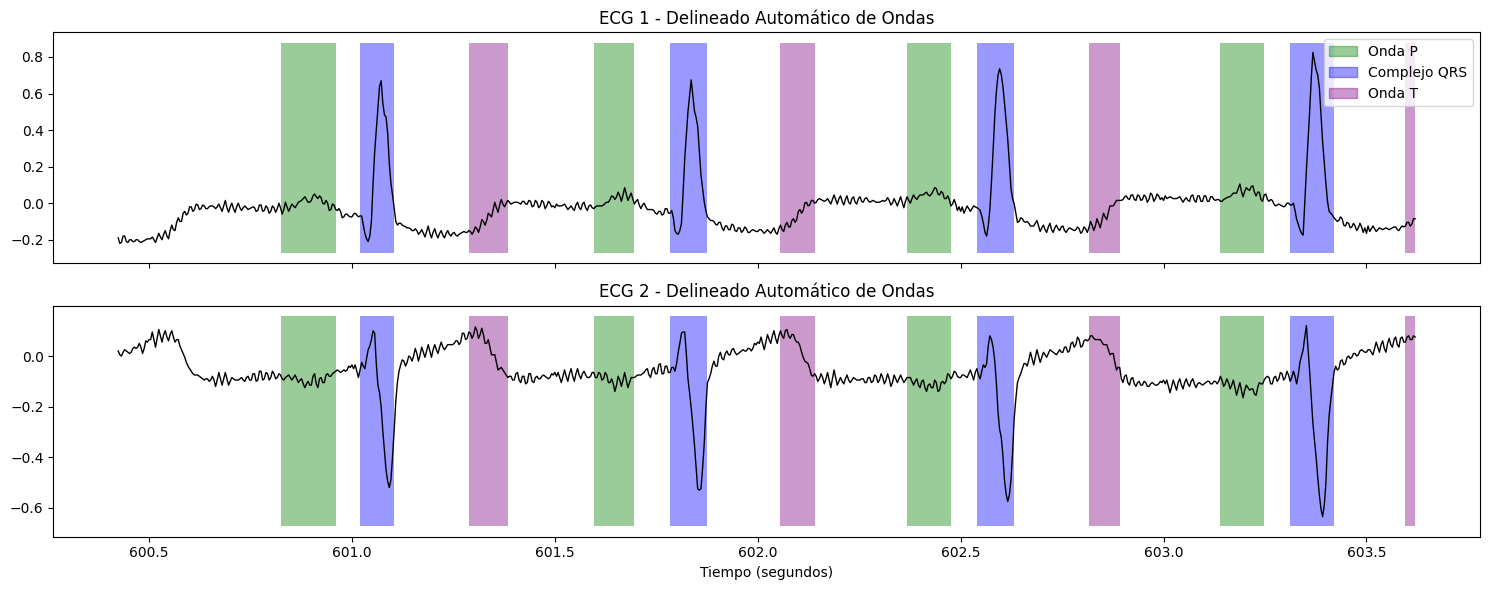

Clase 1 (P): 117
Clase 2 (QRS): 98
Clase 3 (T): 74


In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. BUSCADOR AUTOMÁTICO DEL PRIMER LATIDO ANOTADO
# Buscamos dónde hay algún valor que no sea 0
indices_anotados = np.where(labels != 0)[0]
primer_indice_util = indices_anotados[0]

# Centramos nuestra ventana alrededor de ese latido 
# (ej: 200 puntos antes y 600 después para ver bien la onda)
inicio = primer_indice_util - 100
fin = primer_indice_util + 700

# 2. PREPARAR EL EJE DE TIEMPO
# (Asumimos que fs está definido, en QTDB suele ser 250)
tiempo = np.arange(inicio, fin) / 250

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

ax1.plot(tiempo, record.p_signal[inicio:fin, 0], color='black', linewidth=1)
ax2.plot(tiempo, record.p_signal[inicio:fin, 1], color='black', linewidth=1)

# Forzamos que matplotlib calcule los límites reales ANTES de fill_between
fig.canvas.draw()

ymin1, ymax1 = ax1.get_ylim()
ymin2, ymax2 = ax2.get_ylim()

colores_clases = {
    1: ('green',  'Onda P'),
    2: ('blue',   'Complejo QRS'),
    3: ('purple', 'Onda T')
}

for clase, (color, nombre) in colores_clases.items():
    mascara = (labels[inicio:fin] == clase)
    ax1.fill_between(tiempo, ymin1, ymax1, where=mascara, facecolor=color, alpha=0.4)
    ax2.fill_between(tiempo, ymin2, ymax2, where=mascara, facecolor=color, alpha=0.4)

ax1.set_title('ECG 1 - Delineado Automático de Ondas')
ax2.set_title('ECG 2 - Delineado Automático de Ondas')
ax2.set_xlabel('Tiempo (segundos)')

leyenda = [Patch(color=color, alpha=0.4, label=nombre) 
           for clase, (color, nombre) in colores_clases.items()]
ax1.legend(handles=leyenda, loc='upper right')

plt.tight_layout()
plt.show()
ventana = labels[inicio:fin]
print("Clase 1 (P):", np.sum(ventana == 1))
print("Clase 2 (QRS):", np.sum(ventana == 2))
print("Clase 3 (T):", np.sum(ventana == 3))

In [8]:
def create_window(signal, label, window_size=500, step=250, ratio_silencio=0.25):
    X = []
    y = []
    for i in range(0, len(signal) - window_size + 1, step):
        x_window = signal[i:i + window_size]
        y_window = label[i:i + window_size]
        has_wave = np.any(y_window > 0)
        if has_wave:
            X.append(x_window)
            y.append(y_window)
        else:
            if np.random.random() < ratio_silencio:
                X.append(x_window)
                y.append(y_window)
    return np.array(X), np.array(y)

In [9]:
def apply_z_score(X_windows):
    """
    Recibe un array de ventanas (n_ventanas, 500, 2)
    y normaliza cada una de forma independiente.
    """
    mean = np.mean(X_windows, axis=1, keepdims=True)
    std = np.std(X_windows, axis=1, keepdims=True) + 1e-8
    return (X_windows - mean) / std

In [10]:
from scipy.signal import butter, filtfilt

def filtrar_ecg(signal, fs=250):
    """
    Aplica un filtro Butterworth pasa-banda (0.5Hz - 45Hz) para limpiar la señal.
    """
    nyq = 0.5 * fs
    low = 0.5 / nyq
    high = 45.0 / nyq
    b, a = butter(4, [low, high], btype='band')
    signal_filtrada = np.zeros_like(signal)
    for ch in range(signal.shape[1]):
        signal_filtrada[:, ch] = filtfilt(b, a, signal[:, ch])
    return signal_filtrada

In [11]:
def process_patients(patients_list):
    dir = "../data/qtdb_data/"
    X, y = [], []
    for patient in patients_list:
        record = wfdb.rdrecord(dir + patient)
        fs = record.fs
        ann = wfdb.rdann(dir + patient, "q1c")
        signal_length = len(record.p_signal)
        labels = wave_annotations(ann, signal_length)
        signal_pura = filtrar_ecg(record.p_signal, fs=fs)
        X_w, y_w = create_window(signal_pura, labels, ratio_silencio=0.25)
        X_w = apply_z_score(X_w)
        X.append(X_w)
        y.append(y_w)
    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    return X[indices], y[indices]

Procesamos la base de datos LUDB

In [12]:
def process_ludb(patients_list):
    dir = os.path.join("..", "data", "ludb_data", "data") + os.sep
    X, y = [], []
    for patient in patients_list:
        try:
            record = wfdb.rdrecord(dir + patient)
            fs = record.fs
            signal = record.p_signal[:, :2]
            signal_length = len(signal)
            ann = wfdb.rdann(dir + patient, 'i')
            labels = wave_annotations(ann, signal_length)
            signal_filtrada = filtrar_ecg(signal, fs=fs)
            X_w, y_w = create_window(signal_filtrada, labels,
                                     window_size=500, step=250,
                                     ratio_silencio=0.25)
            if len(X_w) == 0:
                continue
            X_w = apply_z_score(X_w)
            X.append(X_w)
            y.append(y_w)
        except Exception as e:
            print(f"Skipping {patient}: {e}")
 
    if not X:
        return np.array([]), np.array([])
 
    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    return X[indices], y[indices]

In [13]:
patients_train = [
    'sel100', 'sel102', 'sel103', 'sel104', 'sel114',
    'sel116', 'sel117', 'sel123', 'sel213', 'sel221',
    'sel223', 'sel230', 'sel301', 'sel302', 'sel306',
    'sel307', 'sel803', 'sel808', 'sel811', 'sel820',
    'sel821', 'sel840', 'sel847', 'sel853', 'sel871',
    'sel872', 'sel16265', 'sel16272', 'sel16273', 'sel16420',
    'sel16483', 'sel16539', 'sel16773', 'sel16786', 'sele0104',
    'sele0106', 'sele0107', 'sele0110', 'sele0111', 'sele0112',
    'sele0114', 'sele0116', 'sele0121', 'sele0122', 'sele0124',
    'sele0126', 'sele0129', 'sele0133', 'sele0136', 'sele0166',
    'sele0170', 'sele0203', 'sele0210', 'sele0211', 'sele0303',
    'sele0405', 'sele0406', 'sele0409', 'sele0411', 'sele0509',
    'sele0603', 'sel30', 'sel31', 'sel32', 'sel33', 
    'sel34', 'sel35', 'sel36', 'sel37', 'sel38',
    'sel39', 'sel40', 'sel41', 'sel42', 'sel43',
    'sel44', 'sel45', 'sel46', 'sel47', 'sel48',
    'sel14046', 'sel14157'
]

patients_test = [
    'sel231', 'sel232', 'sel233', 'sel308', 'sel310',
    'sel873', 'sel883', 'sel891', 'sel16795', 'sel17453', 
    'sele0604', 'sele0606', 'sele0607', 'sele0609', 'sele0612',
    'sele0704', 'sel49', 'sel50', 'sel51', 'sel52',
    'sel17152', 'sel14172', 'sel15814'
]

In [14]:
ludb_dir = os.path.join("..", "data", "ludb_data", "data")
ludb_records = list(set([
    f.replace('.hea', '')
    for f in os.listdir(ludb_dir) if f.endswith('.hea')
]))
print(f"Pacientes LUDB encontrados: {len(ludb_records)}")
 
from sklearn.model_selection import train_test_split
ludb_train, ludb_test = train_test_split(
    ludb_records, test_size=0.2, random_state=42
)

Pacientes LUDB encontrados: 200


In [15]:
data_dir = "../data"
npy_dir = os.path.join(data_dir, "npy_data_annotations")
 
if not os.path.exists(npy_dir):
    os.makedirs(npy_dir)
 
    # Procesar QTDB
    X_train_qt, y_train_qt = process_patients(patients_train)
    X_test_qt,  y_test_qt  = process_patients(patients_test)
 
    # Procesar LUDB
    X_train_lu, y_train_lu = process_ludb(ludb_train)
    X_test_lu,  y_test_lu  = process_ludb(ludb_test)
 
    # Combinar
    X_train = np.concatenate([X_train_qt, X_train_lu], axis=0)
    y_train = np.concatenate([y_train_qt, y_train_lu], axis=0)
    X_test  = np.concatenate([X_test_qt,  X_test_lu],  axis=0)
    y_test  = np.concatenate([y_test_qt,  y_test_lu],  axis=0)
 
    # Shuffle final
    idx = np.random.permutation(len(X_train))
    X_train, y_train = X_train[idx], y_train[idx]
 
    # Guardar
    np.save(os.path.join(npy_dir, "X_train_DB.npy"), X_train)
    np.save(os.path.join(npy_dir, "y_train_DB.npy"), y_train)
    np.save(os.path.join(npy_dir, "X_test_DB.npy"),  X_test)
    np.save(os.path.join(npy_dir, "y_test_DB.npy"),  y_test)
    print(f"Data saved. Train: {len(X_train)} ventanas | Test: {len(X_test)} ventanas")
 
else:
    print("Data already exists, loading from disk...")
    X_train = np.load(os.path.join(npy_dir, "X_train_DB.npy"))
    y_train = np.load(os.path.join(npy_dir, "y_train_DB.npy"))
    X_test  = np.load(os.path.join(npy_dir, "X_test_DB.npy"))
    y_test  = np.load(os.path.join(npy_dir, "y_test_DB.npy"))
    print(f"Train: {len(X_train)} ventanas | Test: {len(X_test)} ventanas")

Data already exists, loading from disk...
Train: 23323 ventanas | Test: 6578 ventanas


In [16]:
'''
Esto cuando se pase a .py se puede quitar ya que se importará de forma directa (la función normalize)
'''
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D, Conv1DTranspose, Input, Bidirectional, concatenate, BatchNormalization, Dropout
from tensorflow.keras.layers import SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

'''
Modelo secuencial no es optimo ya que el kernel size es muy pequeño
model = Sequential()
model.add(Input(shape=(500, 2)))
model.add(Conv1D(filters=32, kernel_size=11, padding='same', activation='relu'))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(32, return_sequences=True)))
model.add(TimeDistributed(Dense(32, activation='relu')))
model.add(TimeDistributed(Dense(4, activation='softmax')))
'''
input_layer = Input(shape=(500, 2))

conv_low = Conv1D(32, kernel_size=5,  padding="same", activation="relu")(input_layer)
conv_mid = Conv1D(32, kernel_size=15, padding="same", activation="relu")(input_layer)
conv_hi  = Conv1D(32, kernel_size=40, padding="same", activation="relu")(input_layer)
conv_total = concatenate([conv_low, conv_mid, conv_hi])
norm = BatchNormalization()(conv_total)

lstm1 = Bidirectional(LSTM(128, return_sequences=True))(norm)
drop1 = Dropout(0.2)(lstm1)
lstm2 = Bidirectional(LSTM(64, return_sequences=True))(drop1)
drop2 = Dropout(0.2)(lstm2)

output_layer = TimeDistributed(Dense(4, activation="softmax"))(drop2)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 500, 32)   │        352 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 32)   │        992 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 32)   │      2,592 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 500, 96)   │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 500, 96)   │        384 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 500, 256)  │    230,400 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 500, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 500, 128)  │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 500, 128)  │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 500, 4)    │        516 │ dropout_1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 399,588 (1.52 MB)

 Trainable params: 399,396 (1.52 MB)

 Non-trainable params: 192 (768.00 B)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

TRAIN_MODEL = True  # cambiar a True para reentrenar

weights_map = {0: 0.1, 1: 4.0, 2: 5.0, 3: 5.0}
sample_weights = np.vectorize(weights_map.get)(y_train)

model.compile(
    optimizer=Adam(learning_rate=1e-4), #lr demasiado alto, bajar a la mitad o probar con menos
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

model_save = ModelCheckpoint(
    filepath = "../models/labeling_v2_2datasets.keras",
    save_best_only = True,
    verbose = 1,
    monitor = "val_loss"
)

if TRAIN_MODEL:
    print("Starting training...")
    history = model.fit(
        X_train,
        y_train,
        epochs=200,
        batch_size=32,
        validation_data=(X_test, y_test),
        sample_weight=sample_weights,
        callbacks=[early_stop, reduce_lr, model_save]
    )

Starting training...
Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.6831 - loss: 0.1060
Epoch 1: val_loss improved from None to 0.62952, saving model to ../models/labeling_v2_2datasets.keras

Epoch 1: finished saving model to ../models/labeling_v2_2datasets.keras
729/729 ━━━━━━━━━━━━━━━━━━━━ 576s 774ms/step - accuracy: 0.6805 - loss: 0.1069 - val_accuracy: 0.7135 - val_loss: 0.6295 - learning_rate: 1.0000e-04
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.6829 - loss: 0.1051
Epoch 2: val_loss did not improve from 0.62952
729/729 ━━━━━━━━━━━━━━━━━━━━ 566s 776ms/step - accuracy: 0.6842 - loss: 0.1045 - val_accuracy: 0.7040 - val_loss: 0.6734 - learning_rate: 1.0000e-04
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.6914 - loss: 0.1024
Epoch 3: val_loss did not improve from 0.62952
729/729 ━━━━━━━━━━━━━━━━━━━━ 575s 789ms/step - accuracy: 0.6848 - loss: 0.1053 - val_accuracy: 0.6989 - val_loss: 0.6644 - learning_rate: 1.0000

206/206 ━━━━━━━━━━━━━━━━━━━━ 92s 438ms/step


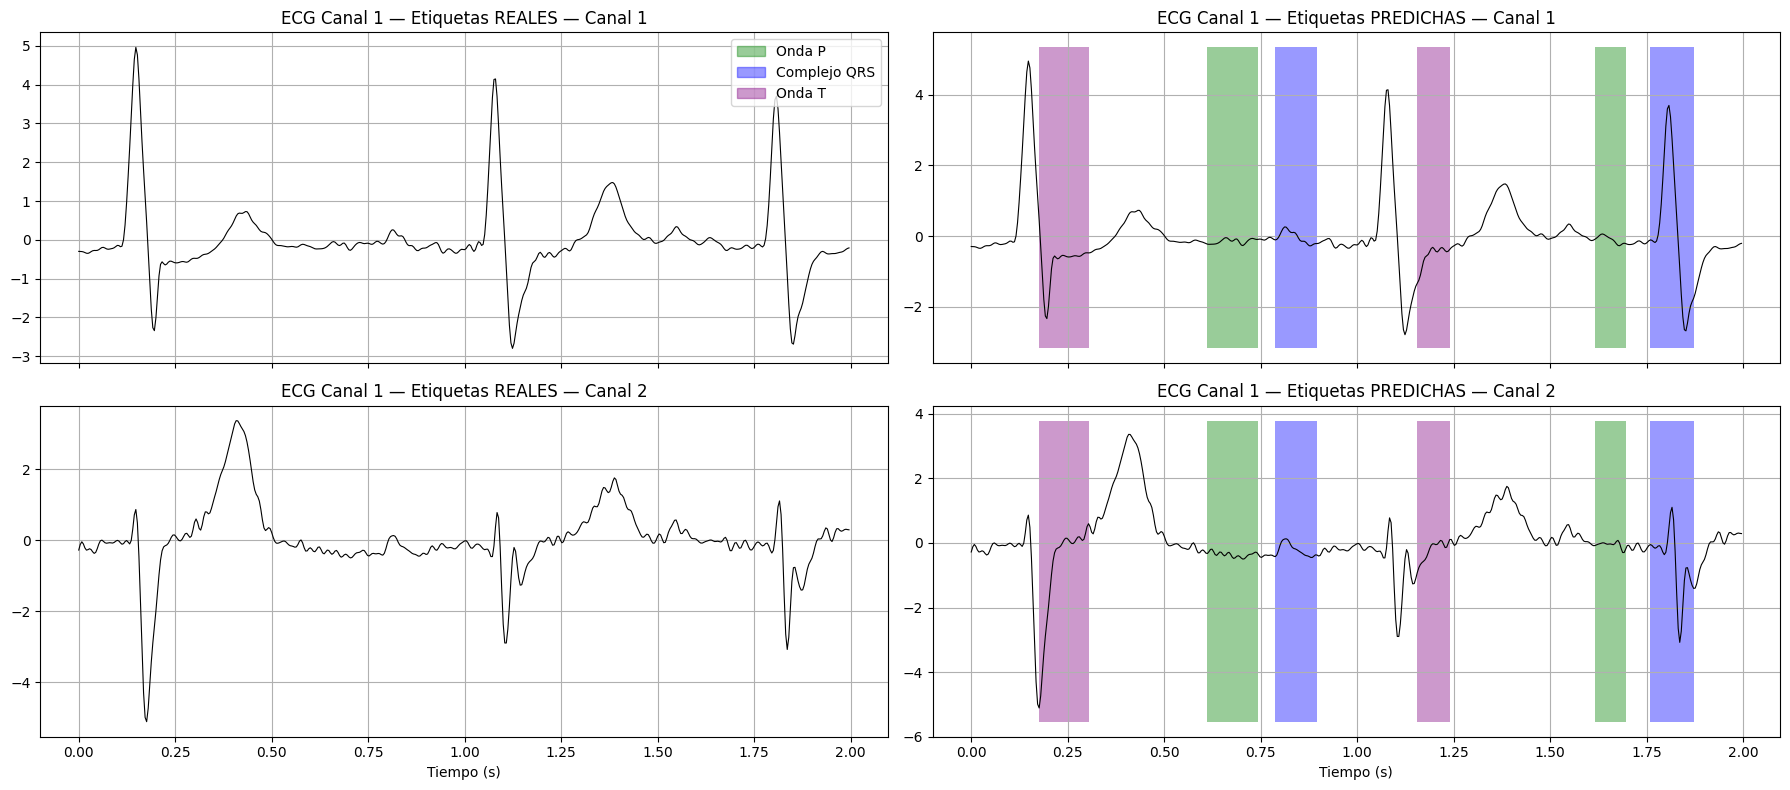

Accuracy en esta ventana: 0.6660
Clase 1 (P)  — Real:   0 | Pred:  55
Clase 2 (QRS)— Real:   0 | Pred:  57
Clase 3 (T)  — Real:   0 | Pred:  55
Clase 0 (BL) — Real: 500 | Pred: 333


In [32]:
from tensorflow.keras.models import load_model

model = load_model("../models/labeling_v1_2datasets.keras", compile=False)

indice = 5

x_ventana = X_test[indice:indice+1]  # shape (1, 500, 2)

# Predecimos — salida shape (1, 500, 4) con probabilidades por clase
pred = model.predict(X_test)

# Cogemos la clase con   mayor probabilidad para cada muestra
pred_clases = np.argmax(pred[0], axis=-1)  # shape (500,)
y_real      = y_test[indice, :]         # shape (500,) — quitamos la dimensión extra

tiempo = np.arange(500) / 250  # eje de tiempo en segundos

colores_clases = {
    1: ('green',  'Onda P'),
    2: ('blue',   'Complejo QRS'),
    3: ('purple', 'Onda T')
}

fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

titulos = [
    ('ECG Canal 1 — Etiquetas REALES',     y_real,      axes[0, 0], axes[1, 0]),
    ('ECG Canal 1 — Etiquetas PREDICHAS',  pred_clases, axes[0, 1], axes[1, 1]),
]

for titulo, etiquetas, ax1, ax2 in titulos:
    ax1.plot(tiempo, X_test[indice][:, 0], color='black', linewidth=0.8)
    ax2.plot(tiempo, X_test[indice][:, 1], color='black', linewidth=0.8)

    fig.canvas.draw()
    ymin1, ymax1 = ax1.get_ylim()
    ymin2, ymax2 = ax2.get_ylim()

    for clase, (color, nombre) in colores_clases.items():
        mascara = (etiquetas == clase)
        ax1.fill_between(tiempo, ymin1, ymax1, where=mascara, facecolor=color, alpha=0.4)
        ax2.fill_between(tiempo, ymin2, ymax2, where=mascara, facecolor=color, alpha=0.4)

    ax1.set_title(f'{titulo} — Canal 1')
    ax2.set_title(f'{titulo} — Canal 2')
    ax1.grid(True)
    ax2.grid(True)

from matplotlib.patches import Patch
leyenda = [Patch(color=c, alpha=0.4, label=n) for _, (c, n) in colores_clases.items()]
axes[0, 0].legend(handles=leyenda)

axes[1, 0].set_xlabel('Tiempo (s)')
axes[1, 1].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

# Métricas rápidas
print(f"Accuracy en esta ventana: {np.mean(pred_clases == y_real):.4f}")
print(f"Clase 1 (P)  — Real: {np.sum(y_real==1):3d} | Pred: {np.sum(pred_clases==1):3d}")
print(f"Clase 2 (QRS)— Real: {np.sum(y_real==2):3d} | Pred: {np.sum(pred_clases==2):3d}")
print(f"Clase 3 (T)  — Real: {np.sum(y_real==3):3d} | Pred: {np.sum(pred_clases==3):3d}")
print(f"Clase 0 (BL) — Real: {np.sum(y_real==0):3d} | Pred: {np.sum(pred_clases==0):3d}")

206/206 ━━━━━━━━━━━━━━━━━━━━ 104s 507ms/step


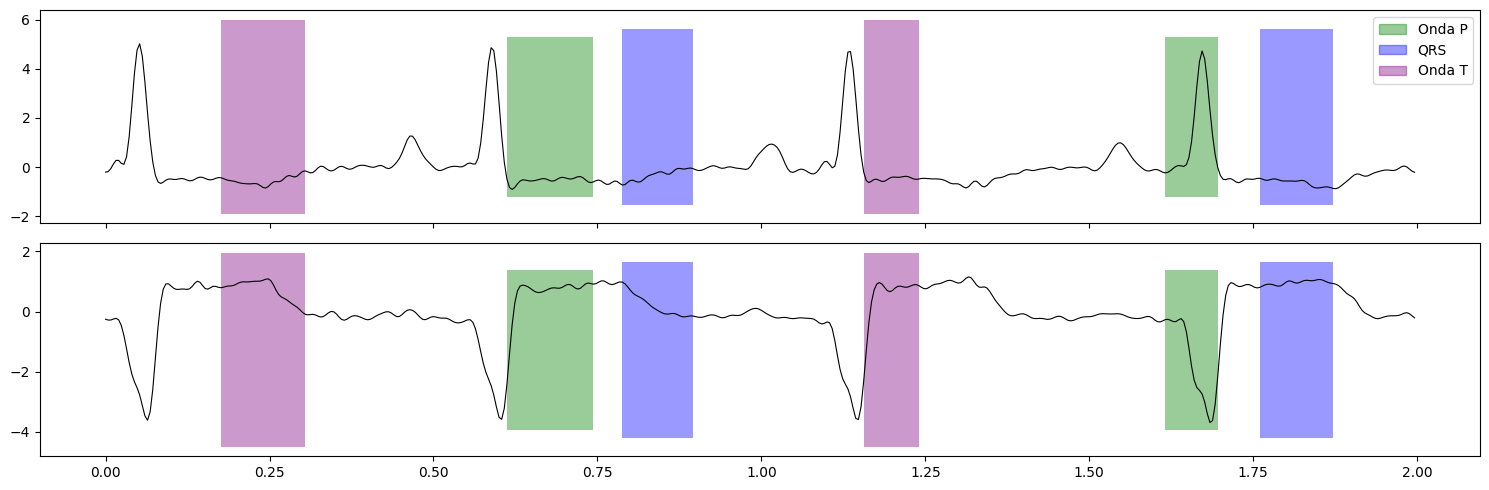

In [23]:
# Coge una ventana "sin anotaciones" y grafícala
indice_sin_ann = 1 # una de las que dio 0 en todo

x_ventana = X_test[indice_sin_ann:indice_sin_ann+1]
pred = model.predict(X_test)
pred_clases = np.argmax(pred[0], axis=-1)

tiempo = np.arange(500) / 250

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
ax1.plot(tiempo, X_test[indice_sin_ann][:, 0], color='black', linewidth=0.8)
ax2.plot(tiempo, X_test[indice_sin_ann][:, 1], color='black', linewidth=0.8)

fig.canvas.draw()
colores = {1: ('green', 'Onda P'), 2: ('blue', 'QRS'), 3: ('purple', 'Onda T')}

for clase, (color, nombre) in colores.items():
    mascara = (pred_clases == clase)
    ax1.fill_between(tiempo, *ax1.get_ylim(), where=mascara, facecolor=color, alpha=0.4)
    ax2.fill_between(tiempo, *ax2.get_ylim(), where=mascara, facecolor=color, alpha=0.4)

from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color=c, alpha=0.4, label=n) for _, (c, n) in colores.items()])
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import classification_report
pred_all  = model.predict(X_test)
pred_flat = np.argmax(pred_all, axis=-1).flatten()
print(classification_report(
    y_test.flatten(), pred_flat,
    target_names=['Silencio', 'Onda P', 'QRS', 'Onda T']
))

206/206 ━━━━━━━━━━━━━━━━━━━━ 115s 558ms/step
              precision    recall  f1-score   support

    Silencio       0.97      0.79      0.87   3025732
      Onda P       0.19      0.65      0.30     68898
         QRS       0.21      0.69      0.32     79562
      Onda T       0.24      0.70      0.36    114808

    accuracy                           0.78   3289000
   macro avg       0.40      0.71      0.46   3289000
weighted avg       0.91      0.78      0.82   3289000



In [37]:
model = load_model("../models/labeling_v2_2datasets.keras", compile=False)
pred_all = model.predict(X_test)

umbral = 0.55
pred_clases = np.zeros(pred_all.shape[:2], dtype=int)
for clase in [1, 2, 3]:
    pred_clases[pred_all[:, :, clase] > umbral] = clase

print(classification_report(
    y_test.flatten(), pred_clases.flatten(),
    target_names=['Silencio', 'Onda P', 'QRS', 'Onda T']
))

print('=' * 50)
model = load_model("../models/labeling_v1_2datasets.keras", compile=False)
pred_all = model.predict(X_test)

umbral = 0.55
pred_clases = np.zeros(pred_all.shape[:2], dtype=int)
for clase in [1, 2, 3]:
    pred_clases[pred_all[:, :, clase] > umbral] = clase

print(classification_report(
    y_test.flatten(), pred_clases.flatten(),
    target_names=['Silencio', 'Onda P', 'QRS', 'Onda T']
))

206/206 ━━━━━━━━━━━━━━━━━━━━ 88s 418ms/step
              precision    recall  f1-score   support

    Silencio       0.96      0.89      0.92   3025732
      Onda P       0.28      0.54      0.37     68898
         QRS       0.30      0.59      0.40     79562
      Onda T       0.35      0.60      0.44    114808

    accuracy                           0.86   3289000
   macro avg       0.47      0.65      0.53   3289000
weighted avg       0.91      0.86      0.88   3289000

206/206 ━━━━━━━━━━━━━━━━━━━━ 97s 455ms/step
              precision    recall  f1-score   support

    Silencio       0.97      0.80      0.87   3025732
      Onda P       0.20      0.63      0.30     68898
         QRS       0.22      0.68      0.33     79562
      Onda T       0.25      0.69      0.37    114808

    accuracy                           0.79   3289000
   macro avg       0.41      0.70      0.47   3289000
weighted avg       0.91      0.79      0.83   3289000



In [41]:
# Métricas solo sobre pacientes QTDB
X_test_QT = np.load(os.path.join("../data/npy_data_QTDB", "X_test_qt.npy"))
y_test_QT = np.load(os.path.join("../data/npy_data_QTDB", "y_test_qt.npy"))
pred_all = model.predict(X_test_QT)
pred_flat = np.argmax(pred_all, axis=-1).flatten()

print("=== QTDB ===")
print(classification_report(
    y_test_QT.flatten(), pred_flat,
    target_names=['Silencio', 'Onda P', 'QRS', 'Onda T']
))
X_test_LUDB = np.load(os.path.join("../data/npy_data_annotations", "X_test_DB.npy"))
y_test_LUDB = np.load(os.path.join("../data/npy_data_annotations", "y_test_DB.npy"))
# Métricas solo sobre pacientes LUDB
pred_all = model.predict(X_test_LUDB)
pred_flat = np.argmax(pred_all, axis=-1).flatten()

print("=== LUDB ===")
print(classification_report(
    y_test_LUDB.flatten(), pred_flat,
    target_names=['Silencio', 'Onda P', 'QRS', 'Onda T']
))

183/183 ━━━━━━━━━━━━━━━━━━━━ 83s 454ms/step
=== QTDB ===
              precision    recall  f1-score   support

    Silencio       0.97      0.79      0.87   2806156
      Onda P       0.10      0.42      0.16     41164
         QRS       0.10      0.47      0.16     44636
      Onda T       0.07      0.50      0.12     34044

    accuracy                           0.78   2926000
   macro avg       0.31      0.55      0.33   2926000
weighted avg       0.94      0.78      0.84   2926000

206/206 ━━━━━━━━━━━━━━━━━━━━ 89s 434ms/step
=== LUDB ===
              precision    recall  f1-score   support

    Silencio       0.97      0.79      0.87   3025732
      Onda P       0.19      0.65      0.30     68898
         QRS       0.21      0.69      0.32     79562
      Onda T       0.24      0.70      0.36    114808

    accuracy                           0.78   3289000
   macro avg       0.40      0.71      0.46   3289000
weighted avg       0.91      0.78      0.82   3289000

